# Hotel Booking Cancellation Prediction
---
## Slide 1: Title & Overview

**Application:** Hotel Revenue Management System

**Description:**  
Hotels lose significant revenue every year due to last-minute booking cancellations.  
This project builds a machine learning model that predicts  at the time of booking  
whether a reservation will be canceled, allowing the hotel to act proactively.

**Goal:**  
Predict which hotel bookings will be canceled before the arrival date,  
so the hotel can send retention offers or apply overbooking strategies to protect revenue.

---
## Slide 2: The Status Quo

## Current Non-ML Solution:
Hotel staff rely on personal experience and intuition to guess which bookings might cancel.  
Some hotels apply simple rule based policies flag bookings with long lead times,  
but there is no data-driven early warning system.

### Limitations:
-  Does not scale  impossible to manually assess 100K+ bookings
-  Inaccurate — human intuition misses complex multi-feature patterns
-  Reactive  revenue is lost *after* cancellation, not prevented before it
-  Inconsistent  depends on individual staff experience

---
## Slide 3: The Case for Machine Learning
## The ML Task
Binary Classification (Canceled vs Not Canceled)

## Why ML?

### Difference
- ⁠  ⁠Predict cancellations before they happen

### Cost
- ⁠  ⁠Development cost is low compared to potential revenue savings

### Expertise
- ⁠  ⁠Requires data science and ML knowledge

### Maintenance 
- Monthly retraining as booking patterns shift seasonally


---
## Slide 4: Data Assessment

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier 
from sklearn.metrics import  accuracy_score, recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from autogluon.tabular import TabularPredictor
import joblib


In [33]:
df= pd.read_csv("/Users/mafahad/Desktop/ai sdaia/Project ML/Machine-Learning-Project-sdaia-Applied-AI-Bootcamp/hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [34]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [35]:
print(f'Shape: {df.shape}')
df.head(3)

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [36]:
missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0])

Missing values:
children         4
country        488
agent        16340
company     112593
dtype: int64


**Quantity & Quality:**
- 119,390 bookings · 32 columns · 37% cancellation rate
- `agent` (16K missing) and `company` (112K missing) → dropped
- `children` has 4 missing values → imputed with median

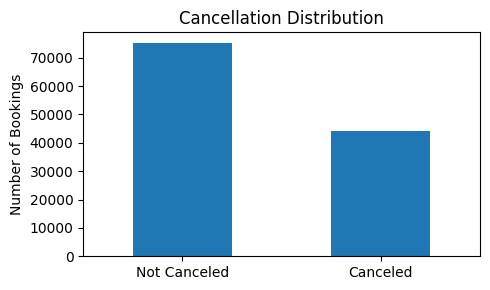

In [37]:
counts = df['is_canceled'].value_counts()
counts.index = ['Not Canceled', 'Canceled']
counts.plot(kind='bar',  figsize=(5, 3), rot=0)
plt.title('Cancellation Distribution')
plt.ylabel('Number of Bookings')
plt.tight_layout()
plt.show()

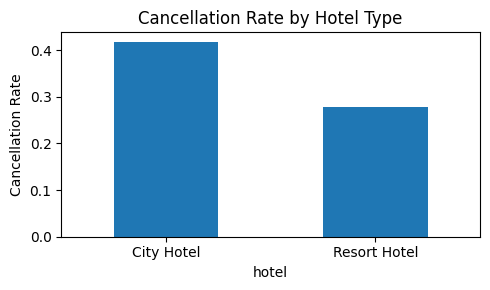

In [38]:
df.groupby('hotel')['is_canceled'].mean().plot(
    kind='bar',  figsize=(5, 3), rot=0)
plt.title('Cancellation Rate by Hotel Type')
plt.ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

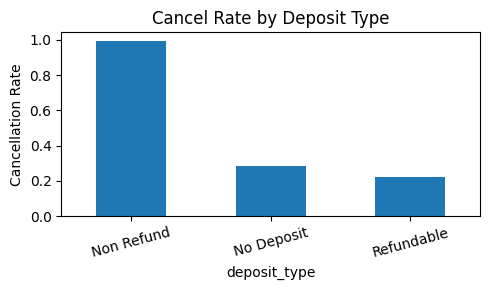

In [39]:
df.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False).plot(
    kind='bar', figsize=(5, 3), rot=15)
plt.title('Cancel Rate by Deposit Type')
plt.ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()


---
## Slide 5: Feature Engineering & Selection

In [40]:
def prepare_data(df):
    df = df.copy()

    df = df.drop(columns=['reservation_status', 'reservation_status_date'])

    df = df.drop(columns=['agent', 'company', 'country', 'reserved_room_type', 'assigned_room_type'])

    df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

    df['total_guests'] = df['adults'] + df['children'] + df['babies']

    df['arrival_date_month'] = pd.to_datetime(
        df['arrival_date_month'], format='%B').dt.month

    return df

df_clean = prepare_data(df)
print(f'Shape beffore cleaning: {df.shape}')
print(f'Shape after cleaning: {df_clean.shape}')
print('Features:', df_clean.drop(columns='is_canceled').columns.tolist())

Shape beffore cleaning: (119390, 32)
Shape after cleaning: (119390, 27)
Features: ['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'deposit_type', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'total_guests']


* `total_nights` weekend + week nights  Total length of stay
* `total_guests`  adults + children + babies  Group size signal 
* `arrival_date_month`  Month name  integer  Enable numerical processing

In [41]:
df_clean.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,previous_bookings_not_canceled,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests
0,Resort Hotel,0,342,2015,7,27,1,0,0,2,...,0,3,No Deposit,0,Transient,0.0,0,0,0,2.0
1,Resort Hotel,0,737,2015,7,27,1,0,0,2,...,0,4,No Deposit,0,Transient,0.0,0,0,0,2.0
2,Resort Hotel,0,7,2015,7,27,1,0,1,1,...,0,0,No Deposit,0,Transient,75.0,0,0,1,1.0
3,Resort Hotel,0,13,2015,7,27,1,0,1,1,...,0,0,No Deposit,0,Transient,75.0,0,0,1,1.0
4,Resort Hotel,0,14,2015,7,27,1,0,2,2,...,0,0,No Deposit,0,Transient,98.0,0,1,2,2.0


---
## Slide 6: Evaluation & Success Criteria

In [42]:
X = df_clean.drop(columns='is_canceled')
y = df_clean['is_canceled']

num_features = X.select_dtypes(include='number').columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)    

In [43]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

## Models Used
•⁠  ⁠Dummy Classifier
•⁠  ⁠Logistic Regression
•⁠  ⁠HistGradientBoosting
•⁠  ⁠AutoGluon

## Result
AutoGluon / HGB achieved best performance

In [44]:
train_ag = pd.concat([X_train, y_train], axis=1)
test_ag  = pd.concat([X_test,  y_test],  axis=1)

predictor = TabularPredictor(
    label= "is_canceled").fit(train_ag)


No path specified. Models will be saved in: "AutogluonModels/ag-20260425_113415"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.12
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.2.0: Tue Nov 18 21:09:55 PST 2025; root:xnu-12377.61.12~1/RELEASE_ARM64_T8103
CPU Count:          8
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       1.18 GB / 8.00 GB (14.7%)
Disk Space Avail:   9.53 GB / 228.27 GB (4.2%)
	We recommend a minimum available disk space of 10 GB, and large datasets may require more.
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/t

[1000]	valid_set's binary_error: 0.154614
[2000]	valid_set's binary_error: 0.147823


	0.8534	 = Validation score   (accuracy)
	14.48s	 = Training   runtime
	0.07s	 = Validation runtime
Fitting model: LightGBM ...
	Fitting with cpus=8, gpus=0, mem=0.1/1.3 GB
	0.847	 = Validation score   (accuracy)
	2.92s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	Fitting with cpus=8, gpus=0, mem=0.4/1.2 GB
	0.861	 = Validation score   (accuracy)
	1.89s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	Fitting with cpus=8, gpus=0, mem=0.4/1.2 GB
	0.8662	 = Validation score   (accuracy)
	1.77s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
	Fitting with cpus=8, gpus=0
	0.8486	 = Validation score   (accuracy)
	80.1s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: ExtraTreesGini ...
	Fitting with cpus=8, gpus=0, mem=0.4/1.3 GB
	0.8638	 = Validation score   (accuracy)
	1.42s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: ExtraTreesEntr ...
	F

[1000]	valid_set's binary_error: 0.13304


	0.867	 = Validation score   (accuracy)
	23.33s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ...
	Fitting 1 model on all data | Fitting with cpus=8, gpus=0, mem=0.0/1.3 GB
	Ensemble Weights: {'ExtraTreesGini': 0.476, 'LightGBMLarge': 0.476, 'LightGBMXT': 0.048}
	0.871	 = Validation score   (accuracy)
	0.05s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 432.93s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 15334.9 rows/s (2503 batch size)
Disabling decision threshold calibration for metric `accuracy` due to having fewer than 10000 rows of validation data for calibration, to avoid overfitting (2503 rows).
	`accuracy` is generally not improved through threshold calibration. Force calibration via specifying `calibrate_decision_threshold=True`.
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/Users/mafahad/Desktop/ai sdaia/Project ML/Machine-Learning-Pro

In [45]:
leaderboard_train = predictor.leaderboard(train_ag)
leaderboard_train[['model','score_test','score_val']].head(10)

,model,score_test,score_val
0,RandomForestEntr,0.988064,0.866161
1,RandomForestGini,0.987918,0.860967
2,ExtraTreesEntr,0.983541,0.863364
3,ExtraTreesGini,0.980788,0.863763
4,WeightedEnsemble_L2,0.954090,0.870955
5,XGBoost,0.924208,0.863763
6,LightGBMLarge,0.919937,0.866960
7,NeuralNetTorch,0.879397,0.850180
8,LightGBMXT,0.865378,0.853376
9,CatBoost,0.861211,0.848582


In [46]:
predictor.evaluate(train_ag)

{'accuracy': 0.9540895384873105,
 'balanced_accuracy': np.float64(0.9434736467952054),
 'mcc': 0.9015855167530299,
 'roc_auc': np.float64(0.9932083798942812),
 'f1': 0.9357462085134443,
 'precision': 0.97152072050143,
 'recall': 0.9025127900732073}

In [47]:
leaderboard_test = predictor.leaderboard(test_ag)
leaderboard_test[['model','score_test','score_val']].head(10)

,model,score_test,score_val
0,RandomForestEntr,0.866279,0.866161
1,RandomForestGini,0.865022,0.860967
2,WeightedEnsemble_L2,0.864855,0.870955
3,ExtraTreesGini,0.864562,0.863763
4,ExtraTreesEntr,0.862174,0.863364
5,LightGBMLarge,0.857735,0.866960
6,XGBoost,0.857316,0.863763
7,LightGBMXT,0.847935,0.853376
8,NeuralNetTorch,0.844711,0.850180
9,CatBoost,0.844501,0.848582


In [48]:
predictor.evaluate(test_ag)

{'accuracy': 0.8648546779462266,
 'balanced_accuracy': np.float64(0.8396627889718558),
 'mcc': 0.7063795771338817,
 'roc_auc': np.float64(0.9327520382236524),
 'f1': 0.8027626673186236,
 'precision': 0.8737360298030867,
 'recall': 0.7424533634821934}

In [49]:
predictor.fit_summary(show_plot=True)

*** Summary of fit() ***
Estimated performance of each model:
                  model  score_val eval_metric  pred_time_val    fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0   WeightedEnsemble_L2   0.870955    accuracy       0.163223   39.274972                0.000382           0.045980            2       True         12
1         LightGBMLarge   0.866960    accuracy       0.043535   23.331161                0.043535          23.331161            1       True         11
2      RandomForestEntr   0.866161    accuracy       0.027119    1.771868                0.027119           1.771868            1       True          4
3               XGBoost   0.863763    accuracy       0.030281    7.588374                0.030281           7.588374            1       True          9
4        ExtraTreesGini   0.863763    accuracy       0.045025    1.419066                0.045025           1.419066            1       True          6
5        ExtraTreesEntr   

{'model_types': {'LightGBMXT': 'LGBModel',
  'LightGBM': 'LGBModel',
  'RandomForestGini': 'RFModel',
  'RandomForestEntr': 'RFModel',
  'CatBoost': 'CatBoostModel',
  'ExtraTreesGini': 'XTModel',
  'ExtraTreesEntr': 'XTModel',
  'NeuralNetFastAI': 'NNFastAiTabularModel',
  'XGBoost': 'XGBoostModel',
  'NeuralNetTorch': 'TabularNeuralNetTorchModel',
  'LightGBMLarge': 'LGBModel',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel'},
 'model_performance': {'LightGBMXT': 0.8533759488613664,
  'LightGBM': 0.8469836196564123,
  'RandomForestGini': 0.8609668397922493,
  'RandomForestEntr': 0.8661606072712744,
  'CatBoost': 0.8485817019576508,
  'ExtraTreesGini': 0.8637634838194167,
  'ExtraTreesEntr': 0.863363963244107,
  'NeuralNetFastAI': 0.8457850579304834,
  'XGBoost': 0.8637634838194167,
  'NeuralNetTorch': 0.8501797842588893,
  'LightGBMLarge': 0.8669596484218938,
  'WeightedEnsemble_L2': 0.87095485417499},
 'model_best': 'WeightedEnsemble_L2',
 'model_paths': {'LightGBMXT': ['LightGBMXT

In [50]:
best_model = predictor.model_best
print(best_model)

WeightedEnsemble_L2


In [51]:
predictor.model_names()


['LightGBMXT',
 'LightGBM',
 'RandomForestGini',
 'RandomForestEntr',
 'CatBoost',
 'ExtraTreesGini',
 'ExtraTreesEntr',
 'NeuralNetFastAI',
 'XGBoost',
 'NeuralNetTorch',
 'LightGBMLarge',
 'WeightedEnsemble_L2']

In [52]:
pipe_dummy = Pipeline(
    [('pre', preprocessor), 
    ('model', DummyClassifier(strategy='most_frequent'))])

pipe_dummy.fit(X_train, y_train)

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [53]:
y_pred_dummy = pipe_dummy.predict(X_test)

accuracy = accuracy_score(y_test,y_pred_dummy)
recall = recall_score(y_test, y_pred_dummy)

print(f"Accuracy: {accuracy:.3f}")
print(f"Recall: {recall:.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, pipe_dummy.predict_proba(X_test)[:,1]):.3f}")
print(classification_report(y_test, y_pred_dummy))


Accuracy: 0.630
Recall: 0.000
ROC-AUC  : 0.500
              precision    recall  f1-score   support

           0       0.63      1.00      0.77     15033
           1       0.00      0.00      0.00      8845

    accuracy                           0.63     23878
   macro avg       0.31      0.50      0.39     23878
weighted avg       0.40      0.63      0.49     23878



/Users/mafahad/Desktop/ai sdaia/Project ML/Machine-Learning-Project-sdaia-Applied-AI-Bootcamp/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mafahad/Desktop/ai sdaia/Project ML/Machine-Learning-Project-sdaia-Applied-AI-Bootcamp/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mafahad/Desktop/ai sdaia/Project ML/Machine-Learning-Project-sdaia-Applied-AI-Bootcamp/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedM

In [54]:
pipe_lr    = Pipeline(
    [('pre', preprocessor), 
    ('model', LogisticRegression(max_iter=500))])

pipe_lr.fit(X_train, y_train)

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [55]:
y_pred_lr = pipe_lr.predict(X_test)

accuracy = accuracy_score(y_test,y_pred_lr)
recall = recall_score(y_test, y_pred_lr)

print(f"Accuracy: {accuracy:.3f}")
print(f"Recall: {recall:.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, pipe_lr.predict_proba(X_test)[:,1]):.3f}")
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.809
Recall: 0.596
ROC-AUC  : 0.852
              precision    recall  f1-score   support

           0       0.80      0.93      0.86     15033
           1       0.84      0.60      0.70      8845

    accuracy                           0.81     23878
   macro avg       0.82      0.76      0.78     23878
weighted avg       0.81      0.81      0.80     23878



In [56]:
pipe_hgb   = Pipeline(
    [('pre', preprocessor), 
     ('model', HistGradientBoostingClassifier())])

pipe_hgb.fit(X_train, y_train)

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [57]:
y_pred_hgb = pipe_hgb.predict(X_test)

accuracy = accuracy_score(y_test,y_pred_hgb)
recall = recall_score(y_test, y_pred_hgb)
y_prob_hgb = pipe_hgb.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy:.3f}")
print(f"Recall: {recall:.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_hgb):.3f}")
print(classification_report(y_test, y_pred_hgb, target_names=['Not Canceled','Canceled']))

Accuracy: 0.837
Recall: 0.675
ROC-AUC  : 0.906
              precision    recall  f1-score   support

Not Canceled       0.83      0.93      0.88     15033
    Canceled       0.86      0.67      0.75      8845

    accuracy                           0.84     23878
   macro avg       0.84      0.80      0.82     23878
weighted avg       0.84      0.84      0.83     23878



In [58]:
y_pred_dummy = pipe_dummy.predict(X_test)
y_pred_lr    = pipe_lr.predict(X_test)
y_pred_hgb   = pipe_hgb.predict(X_test)

y_prob_dummy = pipe_dummy.predict_proba(X_test)[:, 1]
y_prob_lr    = pipe_lr.predict_proba(X_test)[:, 1]
y_prob_hgb   = pipe_hgb.predict_proba(X_test)[:, 1]
y_pred_ag = predictor.predict(X_test)
y_prob_ag = predictor.predict_proba(X_test)[1]


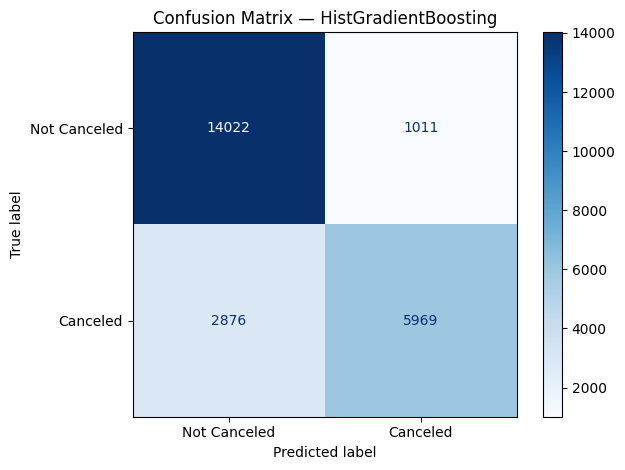

In [59]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_hgb,
    display_labels=['Not Canceled', 'Canceled'],
    cmap='Blues')
plt.title('Confusion Matrix — HistGradientBoosting')
plt.tight_layout()
plt.show()



## ROC Curve Comparison

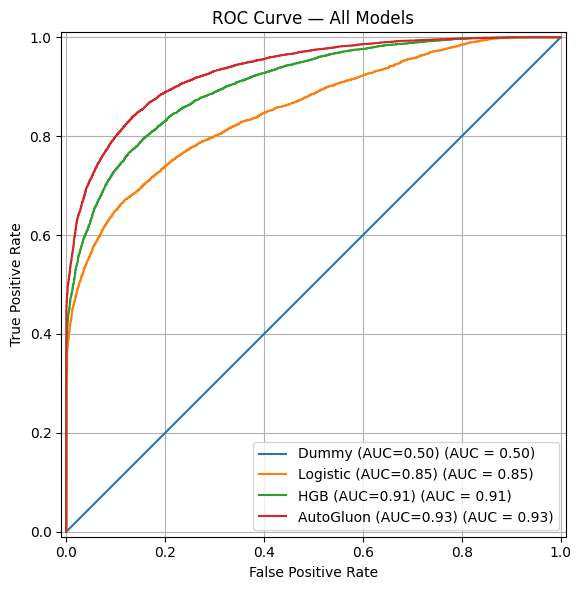

In [60]:
fig, ax = plt.subplots(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test, y_prob_dummy,
    ax=ax,
    name=f"Dummy (AUC={roc_auc_score(y_test, y_prob_dummy):.2f})"
)

RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    ax=ax,
    name=f"Logistic (AUC={roc_auc_score(y_test, y_prob_lr):.2f})"
)

RocCurveDisplay.from_predictions(
    y_test, y_prob_hgb,
    ax=ax,
    name=f"HGB (AUC={roc_auc_score(y_test, y_prob_hgb):.2f})"
)


RocCurveDisplay.from_predictions(
    y_test, y_prob_ag,
    ax=ax,
    name=f"AutoGluon (AUC={roc_auc_score(y_test, y_prob_ag):.2f})"
)



ax.set_title("ROC Curve — All Models")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Conclusion
Machine learning significantly improves cancellation prediction.

## Impact
•⁠  ⁠Reduce revenue loss
•⁠  ⁠Better planning
•⁠  ⁠Smarter decisions

## Future Work
•⁠  ⁠Deploy model
•⁠  ⁠Real-time predictions